In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [13]:
df = pd.read_csv("../data/imoveis_sp_limpo.csv", encoding="utf-8-sig")
df.head()

,bairro,tipo_imovel,area_util,banheiros,suites,quartos,vagas_garagem,preco_venda
0,Jardim da Saúde,Casa de dois andares,388.0,3.0,1.0,4.0,6.0,700000
1,Vila Olímpia,Apartamento,80.0,2.0,1.0,3.0,2.0,739643
2,Pinheiros,Apartamento,94.0,1.0,0.0,3.0,2.0,630700
3,Vila Santa Clara,Condomínio,110.0,1.0,1.0,3.0,2.0,385000
4,Aclimação,Apartamento,141.0,4.0,3.0,4.0,2.0,1106000


In [14]:
df = df.dropna()

# Remove outliers de preço (1% inferior e 1% superior)
q_low  = df['preco_venda'].quantile(0.01)
q_high = df['preco_venda'].quantile(0.99)
df = df[(df['preco_venda'] >= q_low) & (df['preco_venda'] <= q_high)]

print(f'Shape após limpeza: {df.shape}')
df['preco_venda'].describe()

Shape após limpeza: (81153, 8)


count    8.115300e+04
mean     7.581657e+05
std      7.121563e+05
min      1.400000e+05
25%      3.164000e+05
50%      5.109990e+05
75%      9.030000e+05
max      4.900000e+06
Name: preco_venda, dtype: float64

In [15]:
X = df.drop('preco_venda', axis=1)

# Transformação log no target — reduz o efeito dos imóveis caros
y = np.log1p(df['preco_venda'])

# Encoding de variáveis categóricas
X = pd.get_dummies(X, columns=['bairro', 'tipo_imovel'], drop_first=True)

print('Features:', X.shape[1])

Features: 501


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 64922 amostras | Teste: 16231 amostras


In [17]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,        # sem limite de profundidade
    min_samples_leaf=2,    # evita overfitting
    max_features='sqrt',   # padrão recomendado para regressão
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Modelo treinado!')

Modelo treinado!


In [18]:
import joblib
import os

os.makedirs('../data', exist_ok=True)

joblib.dump(
    rf,
    '../data/random_forest_model.pkl'
)

joblib.dump(
    X.columns.tolist(),
    '../data/colunas_modelo.pkl'
)

print('Modelo salvo com sucesso!')

Modelo salvo com sucesso!


In [19]:
pred_log  = rf.predict(X_test)
pred_real = np.expm1(pred_log)   # volta para R$
y_test_real = np.expm1(y_test)

r2_log  = r2_score(y_test,      pred_log)   # R² no espaço log (mais confiável)
r2_real = r2_score(y_test_real, pred_real)  # R² em R$ (referência)
mae     = mean_absolute_error(y_test_real, pred_real)

print(f'R² (espaço log): {r2_log:.4f}')
print(f'R² (valor real): {r2_real:.4f}')
print(f'MAE:  R$ {mae:,.0f}')

R² (espaço log): 0.8840
R² (valor real): 0.7871
MAE:  R$ 163,601


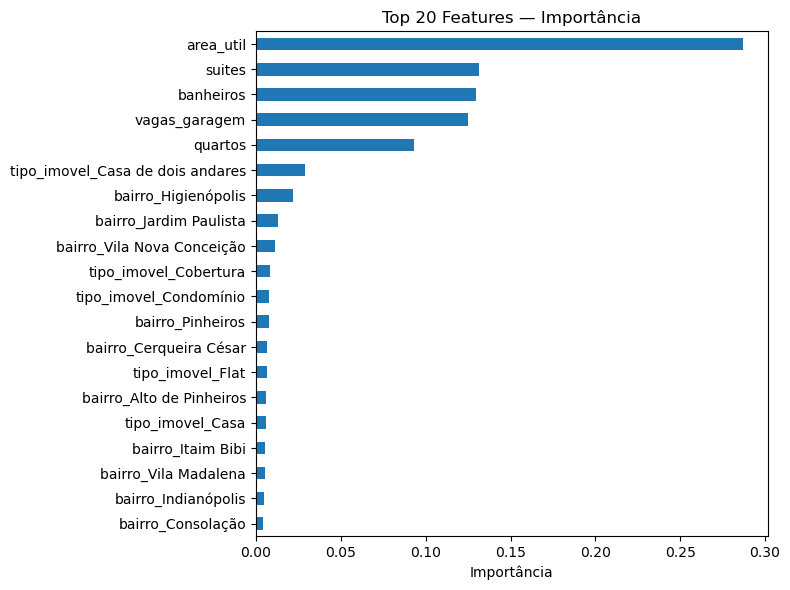

In [21]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

top20.plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 Features — Importância')
plt.xlabel('Importância')
plt.gca().invert_yaxis()

plt.tight_layout()

# salvar imagem
plt.savefig('../graficos/importancia_features.png', dpi=300, bbox_inches='tight')

plt.show()